Model loaded successfully
Video loaded | FPS: 30.0
Starting traffic + pedestrian detection... Press Q to stop
Frame 1: 11 vehicles | 0 pedestrians → MEDIUM TRAFFIC
Frame 2: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 3: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 4: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 5: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 6: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 7: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 8: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 9: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 10: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 11: 8 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 12: 8 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 13: 8 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 14: 8 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 15: 9 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 16: 8 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 17: 7 vehicles | 0 pedestrians → LOW TRAFFIC
Frame 18: 8 vehicles | 0 ped

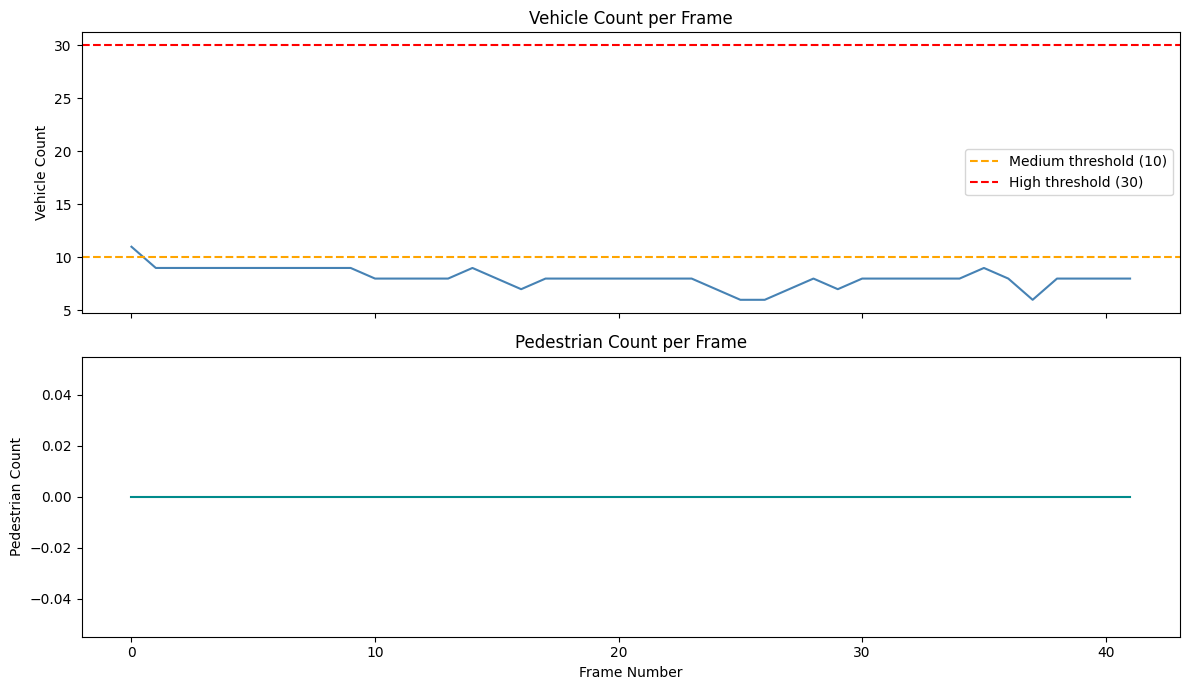

In [2]:
import os
import cv2
import math
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import defaultdict

# ===============================
# STEP 1: LOAD MODEL
# ===============================

MODEL_NAME = "yolov8s.pt"

if not os.path.exists(MODEL_NAME):
    print("Downloading YOLOv8s model (first time only)...")

try:
    model = YOLO(MODEL_NAME)
    print("Model loaded successfully")
except Exception as e:
    print("Model loading failed:", e)
    exit()

# ===============================
# STEP 2: LOAD VIDEO
# ===============================

VIDEO_PATH = "traffic.mp4"

if not os.path.exists(VIDEO_PATH):
    print("ERROR: traffic.mp4 not found in project folder")
    exit()

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    print("ERROR: Cannot open video file")
    exit()

FPS = cap.get(cv2.CAP_PROP_FPS) or 30.0
print(f"Video loaded | FPS: {FPS:.1f}")

# ===============================
# CONFIGURATION
# ===============================

VEHICLE_CLASSES    = ["car", "motorcycle", "bus", "truck"]
PEDESTRIAN_CLASS   = "person"

# Pedestrian confidence is set HIGHER than vehicles intentionally
# This reduces false positives (bags, poles, signs mistaken as people)
VEHICLE_CONF       = 0.35
PEDESTRIAN_CONF    = 0.60   # stricter — only high-confidence humans pass

IOU_THRESHOLD      = 0.50

# A real walking human box should be taller than wide (portrait shape)
# This filters out objects that are square or wide (benches, signboards etc.)
MIN_PERSON_ASPECT  = 1.4    # height must be at least 1.4x the width
MIN_PERSON_HEIGHT  = 60     # ignore tiny boxes — likely noise, not a real person (pixels)

PIXELS_PER_METER   = 20.0
HISTORY_LEN        = 10

CLASS_COLORS = {
    "car":        (0, 200, 0),
    "motorcycle": (255, 165, 0),
    "bus":        (0, 100, 255),
    "truck":      (0, 0, 200),
    "person":     (0, 220, 220),   # yellow-cyan — distinct from all vehicles
}

# ===============================
# TRACKING STATE
# ===============================

track_history  = defaultdict(list)
track_speeds   = defaultdict(float)
frame_number   = 0
vehicle_counts = []
pedestrian_counts = []

# ===============================
# HELPER: Speed Estimation
# ===============================

def estimate_speed(tid, cx, cy):
    history = track_history[tid]
    history.append((cx, cy))
    if len(history) > HISTORY_LEN:
        history.pop(0)

    if len(history) >= 2:
        total_px = sum(
            math.hypot(
                history[i][0] - history[i-1][0],
                history[i][1] - history[i-1][1]
            )
            for i in range(1, len(history))
        )
        avg_px_per_frame = total_px / (len(history) - 1)
        kmh = (avg_px_per_frame / PIXELS_PER_METER) * FPS * 3.6
        track_speeds[tid] = kmh

    return track_speeds.get(tid, 0.0)

# ===============================
# HELPER: Validate Pedestrian Box
# ===============================

def is_valid_pedestrian(x1, y1, x2, y2):
    w = x2 - x1
    h = y2 - y1
    if h < MIN_PERSON_HEIGHT:
        return False                        # too small — likely noise
    if w == 0:
        return False
    aspect = h / w
    if aspect < MIN_PERSON_ASPECT:
        return False                        # too wide — not a human silhouette
    return True

# ===============================
# STEP 3: DETECTION LOOP
# ===============================

print("Starting traffic + pedestrian detection... Press Q to stop")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_number += 1

    # Run with lower vehicle conf — pedestrian filtering is done manually below
    try:
        results = model.track(
            frame,
            persist=True,
            conf=VEHICLE_CONF,      # base conf — pedestrians filtered stricter below
            iou=IOU_THRESHOLD,
            tracker="bytetrack.yaml",
            verbose=False
        )
    except Exception as e:
        print("Detection error:", e)
        break

    annotated      = frame.copy()
    vehicle_count  = 0
    pedestrian_count = 0

    for result in results:
        boxes = result.boxes
        if boxes is None:
            continue

        for box in boxes:
            class_id = int(box.cls[0])
            label    = model.names[class_id]
            conf     = float(box.conf[0])

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            tid = int(box.id[0]) if (box.id is not None) else -1

            # ---- PEDESTRIAN ----
            if label == PEDESTRIAN_CLASS:

                # Gate 1: confidence must meet stricter pedestrian threshold
                if conf < PEDESTRIAN_CONF:
                    continue

                # Gate 2: box shape must match human silhouette
                if not is_valid_pedestrian(x1, y1, x2, y2):
                    continue

                pedestrian_count += 1
                speed_val = estimate_speed(tid, cx, cy) if tid >= 0 else 0.0

                # Walking: 2-7 km/h | Running: 7-15 km/h
                # Anything over 20 km/h for a "person" is likely a false positive
                if speed_val > 20.0:
                    continue

                color = CLASS_COLORS["person"]
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                tag = f"pedestrian | {speed_val:.0f} km/h"
                (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.50, 1)
                cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
                cv2.putText(annotated, tag, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 0, 0), 1)

            # ---- VEHICLE ----
            elif label in VEHICLE_CLASSES:
                vehicle_count += 1
                speed_val = estimate_speed(tid, cx, cy) if tid >= 0 else 0.0

                color = CLASS_COLORS.get(label, (200, 200, 200))
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                tag = f"{label} | {speed_val:.0f} km/h"
                (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 1)
                cv2.rectangle(annotated, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
                cv2.putText(annotated, tag, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 1)

            # Everything else (bags, animals, signs etc.) — silently ignored

    vehicle_counts.append(vehicle_count)
    pedestrian_counts.append(pedestrian_count)

    # Traffic density overlay
    if vehicle_count < 10:
        density, d_color = "LOW TRAFFIC",    (0, 200, 0)
    elif vehicle_count < 30:
        density, d_color = "MEDIUM TRAFFIC", (0, 165, 255)
    else:
        density, d_color = "HIGH TRAFFIC",   (0, 0, 255)

    cv2.putText(annotated, f"{density} | Vehicles: {vehicle_count}",
                (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, d_color, 3)
    cv2.putText(annotated, f"Pedestrians: {pedestrian_count}",
                (50, 95), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 220, 220), 3)

    cv2.imshow("AI Traffic Analyzer", annotated)
    print(f"Frame {frame_number}: {vehicle_count} vehicles | {pedestrian_count} pedestrians → {density}")

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ===============================
# STEP 4: CLEANUP
# ===============================

cap.release()
cv2.destroyAllWindows()

# ===============================
# STEP 5: GRAPH OUTPUT
# ===============================

if vehicle_counts:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax1.plot(vehicle_counts, color="steelblue", linewidth=1.5)
    ax1.axhline(10, color="orange", linestyle="--", label="Medium threshold (10)")
    ax1.axhline(30, color="red",    linestyle="--", label="High threshold (30)")
    ax1.set_title("Vehicle Count per Frame")
    ax1.set_ylabel("Vehicle Count")
    ax1.legend()

    ax2.plot(pedestrian_counts, color="darkcyan", linewidth=1.5)
    ax2.set_title("Pedestrian Count per Frame")
    ax2.set_xlabel("Frame Number")
    ax2.set_ylabel("Pedestrian Count")

    plt.tight_layout()
    plt.show()
else:
    print("No data collected")